# 방정식

이제는 방정식부터 출발하여 SymPy의 좀 더 구체적인 수학적 맥락에서의 활용을 다뤄보려고 합니다.

In [1]:
import sympy as sy
from sympy import S
sy.init_printing()

## 심파이의 등식 관계

컴퓨터 대수에서는 일반적으로 수학적으로 "같다" 라는 개념을 어떻게 다루는지가 주요한 문제 중 하나입니다.

왜냐하면 같다는 개념이 컴퓨터로 넘어오면 좀 모호하거든요.

같다는게 뭐가 그리 모호하고 복잡하다고 근들갑인지 싶으실 수 있으나, 생각보다 같다는 개념은 여러 의미를 가집니다.

대충 같다는 개념은 다음으로 나눌 수 있습니다.

1.  두 표현간의 구조적인 같음
2.  증명하고자하는 명제로서의 두 표현의 같음
3.  미지수를 구하는 방정식을 표현하는 등호의 같음(같아야 한다 라는 의미;)

여기서 우선 구조적인 같음을 좀 잘 이해해야합니다. 

이 놈은 수학적 맥락에서의 구조적으로 같음을 의미하는 게 아니구요, 표현이 SymPy에 의해 저장되는 그 구조가 같은 경우를 의미합니다.

그냥 간단하게 말해서, 1차적으로 수학적으로 두 표현이 같은 표현이고, 또 그 표현들의 저장되는 형태(표현 타입)가 같은 경우,

우리는 두 표현이 구조적으로 같다고 이야기합니다.

대충 어떤 의미인지를 알기 위해서 우선 간단한 예시를 보시죠. 

우선 수학적으로 $x + x + 2= 2(x+1)$는 참입니다.

그리고 좌변, 우변의 두 표현의 타입도 둘 다 SymPy는 `Add`라는 덧셈 표현 객체로 저장합니다.

In [2]:
x = sy.symbols('x')

print(type(x+x+2))   # Add 객체 타입
print(type(2*(x+1))) # Add 객체 타입

x + x + 2 == 2 * (x + 1)

<class 'sympy.core.add.Add'>
<class 'sympy.core.add.Add'>


True

여기서 `x+x+2`와 `2*(x+1)`은 SymPy의 객체 타입도 같고, 수학적으로도 같은 표현이므로 `==` 시 `True`가 반환됩니다.

하지만 다음을 실행해보시죠.

In [3]:
(x + 1) ** 2 == x**2 + 2*x + 1

False

이 놈은 신기하게도, 좌변도 $(x+1)^2 = x^2+2x+1$이고, 우변도 $x^2+2x+1$라 수학적으로 같은 표현임에도 불구하고, 

둘이 서로 다르다는 결과를 반환합니다. 그러면 그 말은 두 표현의 객체 타입이 다르다는건데요, 한 번 확인해보시죠.

In [4]:
print(type((x+1)**2))
print(type(x**2+2*x+1))

<class 'sympy.core.power.Pow'>
<class 'sympy.core.add.Add'>


간단합니다. 우변은 뭐 볼거도 없이 간단한 `Add` 형태의 객체로 정의되는데요, 

좌변은 이와 달리 거듭제곱되는 표현을 위한 객체인 `Pow`라는 놈이 됩니다.

따라서 두 표현은 수학적으로는 같으나, 구조적으로는 다른 표현들이라고 할 수 있습니다.

근데 여기서 이상한 점이 있죠. 위에서 다룬 `2*(x+1)`이라는 친구도, 사실 덧셈이 아니라 곱셈의 형태잖아요?

그래서 SymPy에 있는 곱셈에 관한 표현을 위한 객체인 `Mul`이 되지 않나, 그래서 구조적으로 달라야하는거 아닌가 싶을 수 있어요.

하지만 그렇지가 않습니다. 

기본적으로 `Mul`이라는 객체는 상징과 상징이 곱해지는 형태의 표현들을 저장하기 위해 사용되는 객체입니다.

따라서 `2*(x+1)`이라는 상수와 상징을 곱하는 형태는 그냥 자동으로 `2*x + 2`로 전개하여, `Add`로 정의합니다.

SymPy는 이렇게 상수 곱하기 상징의 형태는, 전부 전개해서 풀어 놓는 형태가 가장 단순하다고 생각하여 그걸 디폴트로 하거든요.

어 그러면 여기서 다시, 위의 `(x+1)**2`는 왜 전개해서 `Add`로 정의하지 않는가 하실 수 있는데요,

거기에도 이유가 있습니다. `2*(x+1)`같이, 상수와 상징의 표현이 곱해진 형태는 전개가 간단합니다.

그리고 실제로 이런 상수 곱하기 상징 형태의 표현을 다른 거랑 연산하거나 치환하거나 하는 경우에서도, 전개된 채로 다루는 게 편하죠.

반면 `(x+1)**2`같이 상징 표현의 거듭제곱 형태의 놈은 전개가 매우 어렵습니다. 지금은 지수가 2라서 그냥 간단히 전개가 되지만,

예를 들어 `(x+1)**100`이라면, 이거 전개하는데 한참 걸리겠죠? 그래서 얘는 `Pow`라는 다른 객체로 저장하는거에요.

SymPy는 저장 시 가장 간단하다고 생각하는 형태로 저장하는데, 상수 곱하기 표현은 전개하는 게 간단하고, 

거듭제곱은 전개하지 않는 게 간단하다고 판단하여 저장하기 떄문에 저런 차이가 발생하는겁니다.

이 내용들을 모두 정리하면 다음과 같습니다.

- 심파이에서 두 표현의 같음은 1차적으로 객체 타입이 같고, 2차적으로 수학적으로 같은 경우를 의미한다.
- 따라서 구조적으로 같으려면 일단 타입이 같아야한다.(타입이 다르면 즉시 나가리)
- 심파이에서 표현들의 등호 연산 `==`는 이런 방식으로 `True/False`를 반환한다.
- 따라서 우리는 단순히 `==`의 결과가 `False`라고, 두 식이 실제로 수학적으로 다르다고 확신할 수는 없다.
- 상수 곱하기 상징 표현의 형태의 경우, 저장 시 전개된 형태로 생각하여, `Mul`이 아닌 `Add`로 저장된다.
- (같은) 표현의 거듭제곱은 `Pow` 형태로 저장된다.
- (서로 다른) 표현간의 곱은 `Mul` 형태로 저장된다.

이 쯤 되면 근데 굳이 왜 이딴 식으로 구조적인 등호를 디폴트 등호로 사용하는지 의문스러우실겁니다.

그 이유는 수학적 등호와 달리, 구조적 등호는 결정 가능성을 보장하기 떄문입니다.

이건 또 컴퓨터 동작 원리의 매우 기저에 있는 형식 시스템 등의 컴퓨터 과학적인 논리 이론으로 들어가서 설명하면 머리아프니까,

간단하게만 설명해볼게요. 결정 가능성은 컴퓨터가 쉽게 일련의 과정을 통해서, 어떤 명제가 맞는지를 판단할 수 있는지를 의미합니다.

결정 가능성이 없다는건 한 마디로 두 표현이 같다는걸 판별하는 방법을 컴퓨터도 알아듣게끔 일련의 구조를 통해 형식화할 수 없다는겁니다.

`(x+1)**2 == x**2+2*x+1`같은 간단한 식은 모르겠으나, 엄청 복잡한 식이 주어지더라도 그 식을 컴퓨터에 저장시켜서 

수학적으로 같은지 판별할 수 있는 형식적인 방법이 없다는거에요. 떄문에 심파이는 우선 구조가 같은가, 그 이후에 수학적으로 같은가를 판별합니다.

심파이에서 객체들은 각자의 타입에 따라서 컴퓨터가 하나 하나 단순 비교로 서로 같은지를 비교할 수 있도록 설계되어 있습니다. 

따라서 컴퓨터는 같은 타입의 표현들이 주어진다면, 그 표현 인스턴스들에 들어있는 속성값을 비교하여

매우 빠르게 수학적으로 같은지 아닌지를 판별할 수 있는거에요.

기본적인 수학적 같음을 넘어서서, 객체로서 저장되는 구조가 같은지가 주어진다면 이러한 결정 가능성이 보장되는거죠.

이 떄문에 SymPy는 기본적으로 구조적인 같음을 디폴트로 사용합니다.

그럼에도 우리는 주어진 식이 대충 어떤 식인지 알고 있다면, 수학적 같음을 비교할 수 있습니다.

위의 `(x+1)**2 == x**2+2*x+1`의 경우, 결국 두 객체의 타입이 맞지 않는거니까 그걸 맞춰주면 되겠죠.

따라서 우리는 좌변의 `Pow` 객체를 `expand()`로 풀어서 둘을 비교하여 수학적 같음을 얻어낼 수 있습니다.

In [5]:
sy.expand((x + 1) ** 2) == x**2 + 2*x + 1

True

근데 이 경우는 간단해서 망정이지, 복잡한 식들은 이걸 전개해야할지, 뭘 어캐해서 같은 객체 타입으로 만들어줄 지 불확실할 수 있습니다.

이 떄는 다음과 같은 트릭을 사용합니다.
```python
sy.expand(expr1 - expr2) == 0

# 혹은

sy.simplify(expr1 - expr2) == 0
```

`expr1`, `expr2`가 같은지를 비교하기 위해서, 두 표현을 한 쪽으로 몰아 위와 같이 전개나 단순화 함수를 적용하여

하나의 객체로 만들어준 뒤, 우리는 이를 `Integer(0)`과 비교할 수 있습니다.

그러면 `expr1 - expr2`가 수학적으로 같아서, 저 내부 연산을 수행하는 도중에 0, 즉 `Integer(0)`이 되는 경우,

우리는 양 변의 구조적 같음에 의해 `True`를 받아볼 수 있고,

만약 `expr1-expr2`가 수학적으로 같지 않아, 저 내부 연산을 수행하더라도 어떤 `Add`, `Mul` 등의 다른 표현 객체가 나오는 경우,

결과적으로 우변에 있는 `Integer(0)`과는 객체 타입이 맞지 않아 `False`가 나오게 됩니다.

방정식 같이 등식 관계가 중요한 맥락에서 SymPy를 사용하는 경우에는 이 등식의 구조를 잘 이해하는 게 매우 중요합니다.

## 방정식

SymPy에는 방정식을 위한 객체가 따로 존재합니다.

~~~python
sy.Eq(lhs, rhs=0)
~~~

간단해요. `lhs`는 말 그대로 좌변(left hand side), `rhs`는 우변(right hand side)입니다.

여기에는 각각 표현들이 들어갈 수 있고, 일반적으로 방정식은 $f(x) = 0$의 형태이므로, 우변의 `rhs`는 디폴트로 0이 들어있습니다.

예를 들어 $x^2 = 2$라는 방정식은 다음으로 나타낼 수 있습니다.

In [6]:
sy.Eq(x**2, 2)

In [7]:
import sympy as sy

x = sy.symbols('x')

expr = x = 4 # 이런식으로는 방정식 못 만듭니다.
expr

## 방정식의 풀이

이 방정식 객체의 매우 좋은 존재 이유는 함수 `sy.solveset()입니다 :

~~~python
sy.solveset(equations,variable=None, domain=S.Complexes)
~~~

일단 입력 매개변수들은 다음과 같습니다.

-   `equations`: 위에서 다룬 `Eq` 객체 혹은 표현이 들어옴. 방정식계의 경우, 이들을 리스트에 넣어서 전달하면 됨.
-   `variable`: 방정식에서 푸는 기준이 되는 변수 상징(변수는 하나만)
-   `domain`: 방정식의 변수가 고려될 영역(`S.Complexes`는 복소수(디폴트), `S.Reals`는 실수, `S.Naturals`는 자연수 등)

이렇게 매개변수들을 넣으면 해당 함수는 방정식의 해집합을 반환해줍니다.

$x^2 = 2$라는 방정식은 다음과 같이 풀 수 있습니다.

In [8]:
sy.solveset(sy.Eq(x**2, 2), x)

그리고 $x^2 = 2$를 $x^2-2=0$으로 바꾸는 등 방정식을 우변이 0이 되도록 동치 변환 가능하다면, 

우리는 방정식 대신에 그냥 좌변의 표현 $x^2-2$를 `equations` 자리에 넣을 수 있습니다 : 

In [9]:
sy.solveset(x**2 - 2, x)

이렇게 표현 `expr`을 직접 넣는 경우, 자동으로 해당 함수는 방정식 $expr = 0$의 형태로 고려하여 해를 구합니다.

사실 가능하다면 이렇게 표현을 직접 넣는게 내부적으로도 더 빨리 작동합니다 ㅋㅋ 

방정식을 넣는다고해도, 해당 함수는 내부적으로 방정식을 결국 $lhs = 0$의 형태로 바꾼 후 해를 구하거든요.

그리고 위에서도 설명한대로 `solveset()`의 `variable`은 하나 밖에 지정할 수 없습니다.

따라서 만약 $x^2-y^2 = 0$를 $x$에 대해 푼다면, 그 결과는 다음이 됩니다.

In [10]:
x,y,z = sy.symbols('x,y,z')
sy.solveset(x**2-y**2,x)

만약 `variable`을 입력하지 않는다면, 함수는 자기 마음대로 방정식에 등장하는 상징을 하나 골라서 해를 구합니다.

또 위에서도 설명했듯이, 기본적으로 `domain`은 `S.Complexes`, 즉 복소수 영역으로 설정되어 있습니다 :

In [11]:
eqn = (x-1)**5*(x**2+1)
sy.solveset(eqn)

In [12]:
sy.solveset(eqn, domain=sy.S.Reals)

### 선형방정식계

수치적 방법에서 가장 높은 빈도로 사용되는 방정식의 풀이는 선형방정식의 풀이입니다.

이는 NumPy의 방법으로도 풀 수 있겠으나, SymPy에서는 함수 `sy.linsolve(system,*symbols)`를 이용할 수 있습니다. 

~~~python
sy.linsolve(system, *symbols)
~~~

- `system` : 선형 방정식의 `Eq`형태의 객체, 혹은 선형 방정식 표현들의 리스트가 들어옵니다.
- `*symbols` : 입력된 `system`에 등장하는 상징들 중 미지수들을 입력합니다. 이 떄는 리스트가 아니라, `x,y,z,..`와 같이 입력합니다.

간단합니다. 방정식을 넣고, 어떤 미지수인지를 알려주면 뚝딱이에요.

다만 `*symbols`의 `*`는 가변 인자를 받겠다는 의미입니다. 가변 인자는 말 그대로, 몇 개인지를 정하지 않았다는거에요.

그래서 우리는 `sy.linsolve(system,x,y,z,u,v,...)`이런식으로 계속해서 미지수를 넣어줄 수 있습니다.

리스트나 투플을 넣어도 되긴하는데(SymPy가 알아서 내부적으로 언패킹함), 일단 구조 자체는 저렇게 정의되어있습니다.

In [13]:
lgs = [x+y -1 , x-y - 1]
sy.linsolve(lgs,x,y)

### 비선형 방정식계

SymPy는 비선형 방정식계도 매우 간단하게 풀어줍니다. 그냥 다음과 같이요.

~~~python
sy.nonlinsolve(system, *symbols)
~~~

파라미터들의 구조는 `sy.linsolve()`와 완전 동일합니다.

예를 들어 $x^2-y^2 = 0$, $x+y = 1$를 만족하는 $(x,y)$는 다음과 같이 구할 수 있습니다.

In [14]:
x,y = sy.symbols('x,y')

sol = sy.nonlinsolve([x**2-y**2, x+y -1],(x,y))
sol

`linsolve()`나 `nonlinsolve()`나 둘 다 결국 해집합을 반환하게 되는데요,

만약 그 집합이 유한 집합(`FiniteSet`)일 경우, 그 해는 다음과 같이 해집합의 속성 `args`를 순서대로 불러서 확인이 가능합니다

In [15]:
sol.args[0]

`sol.args`는 우리의 해들을 투플에 담은 형태의 속성입니다.

다만 이렇게 직접적으로 인덱싱할 경우, 해의 순서가 일정하지 않을 수도 있는 등 좀 불안정할 수 있으므로,

다음의 방법으로 리스트화하여 사용하셔도 좋습니다.

In [16]:
list(sol.args)

그리고 우리는 기본적으로 미지수의 상징들을 `x`, `y`, `z`의 형태인거처럼 다뤘었는데요,

미지수들은 표현, 예를 들어 `y**2` 등을 사용할 수도 있습니다 :

In [17]:
sol = sy.nonlinsolve([x**2+y**2+z**2 - 4 , (x-1)**2 +y**2 + z**2 -4],(x,y**2))
sol

그러면 당연히 저 해의 두번째 성분은 $y^2$의 값이 됩니다.


## 부등식

부등식들의 경우, SymPy의 부분 모둘인 `sympy.solvers.inequalities`을 이용하여 풀 수 있습니다.

이름으로부터 아실 수 있듯이, 해당 하위 모둘에는 부등식을 풀 수 있는 풀이 알고리즘(Solver)가 매우 많이 들어있는데요,

우리는 그냥 간단하게 부등식을 간단화하는 `reduce_inequalities()`라는 함수만을 보고 넘어가려고 합니다 :

~~~python
sympy.solvers.inequalities.reduce_inequalities(inequalities,symbols=[])
~~~

사용법도 간단합니다 :

In [18]:
from sympy.solvers.inequalities import reduce_inequalities

reduce_inequalities(x**2 <= 1)

In [19]:
reduce_inequalities([x <=4,x>=1])

보시다시피 부등 표현을 넣어주면 그걸 간단화해주며, 리스트 형태로 부등 표현을 복수 넣으면, 

이 부등 관계가 and로 묶여있다고 판단하여 그 모두를 합쳐줍니다.

파라미터 중 `symbols = []`에는 당연히 해당 부등 관계에서 변수로 작용할 상징들이 들어옵니다.

이 함수는 두 함수의 함수값을 비교하여 정의역의 구간을 생각할 때 매우 요긴하게 사용할 수 있습니다.

In [20]:
f = x**3+x**2 # x^3 + x^2
g = 2*x**4    # 2x^4

reduce_inequalities(f < g) # f<g인 x의 범위를 모두 알려줍니다.

## 행렬

SymPy에도 NumPy처럼 `Matrix`라는 행렬을 위한 클래스가 존재합니다.

우리는 이 객체를 이용하면 상징으로서의 행렬을 정의하여, 이 위에서 연산이 가능합니다.

```python
sy.Matrix([
    [],    #여기서 각 대괄호 안에는 행벡터를 적습니다.
    [], 
    [],... 
    [] 
])
```


생성 방법은 Numpy와 동일하게, 그냥 상징, 숫자, 표현들로 구성된 리스트(행벡터)의 리스트를 넣어주면 됩니다.

In [21]:
A= sy.Matrix([[x, 2], [3, 4]])
A

⎡x  2⎤
⎢    ⎥
⎣3  4⎦

이러한 행렬 객체에는 `transpose`, `det`, `inv` 등의 쓸만한 행렬을 위한 메소드들이 많이 들어있습니다.

In [22]:
A.inv() # 역행렬을 상징적으로 구해줍니다. 개쩔죠?

⎡   2       -1   ⎤
⎢───────  ───────⎥
⎢2⋅x - 3  2⋅x - 3⎥
⎢                ⎥
⎢  -3        x   ⎥
⎢───────  ───────⎥
⎣4⋅x - 6  4⋅x - 6⎦

`sy.Matrix()`는 행렬 뿐 아니라 벡터도 생성할 수 있습니다.

벡터도 결국 행 혹은 열의 크기가 1일 뿐, 행렬의 일종으로도 생각할 수 있으니까요.

이 때, 다음과 같이 정의한다면

```python
sy.Matrix([a, b, c])
```

기본적으로 SymPy는 저걸 행벡터가 아닌, 열벡터 $\begin{pmatrix}  a\\b\\c \end{pmatrix}$로 생각합니다.

여튼 이걸 이용하면 다음과 같이 `Solve()`메소드로 선형 방정식도 풀 수 있습니다.

In [23]:
A = sy.Matrix([[1, x], [3, 4]])
b = sy.Matrix([7, 2])
sol = A.solve(b)
sol

⎡2⋅x - 28⎤
⎢────────⎥
⎢3⋅x - 4 ⎥
⎢        ⎥
⎢ -19    ⎥
⎢─────── ⎥
⎣4 - 3⋅x ⎦

이걸로 얻은 해답과 행렬을 곱하면 우리는 다음의 형태를 얻습니다

In [24]:
A*sol

⎡    19⋅x     2⋅x - 28 ⎤
⎢ - ─────── + ──────── ⎥
⎢   4 - 3⋅x   3⋅x - 4  ⎥
⎢                      ⎥
⎢3⋅(2⋅x - 28)     76   ⎥
⎢──────────── - ───────⎥
⎣  3⋅x - 4      4 - 3⋅x⎦

뭔가 이상하죠. 우리는 $Ax = b$인 $x$를 구한거니, 결과는 $\begin{pmatrix} 7\\2\end{pmatrix}$가 되어야 할텐데 말이죠.근데 그렇게까지 말이 안되는 결과는 아닙니다.

자세히 보시면, 저 식은 완전히 덧셈이 끝나지 않은 형태입니다. 

첫번쨰 성분도 두번쨰 성분도 각 항에 등장하는 분수들의 분모를 동일시할 수 있으므로, 더하면 더 간단화가 가능합니다.

실제로 `simplify()` 혹은 `expand()` 메소드를 사용하면 다음의 결과를 얻을 수 있습니다.

In [25]:
sy.simplify(A*sol)

⎡7⎤
⎢ ⎥
⎣2⎦

# 미분

SymPy는 미분도 가능합니다!

## 미분의 정의

미분의 정의부터 간단하게 훑어볼게요.

어떤 함수 $f: D\to \mathbb{R}$가 $x_0 \in D$에서 미분 가능함은 다음의 극한값이 존재함으로 정의됩니다.

$$
\lim_{x \to x_0} \frac{f(x) - f(x_0)}{x - x_0}\in \mathbb{R}
$$

$f$가 $x_0$에서 미분 가능하면, $x_0$에서 연속입니다.

그리고 $f$가 $x_0$에서 미분 가능한 경우, 우리는 위의 극한값을 $f$의 $x_0$에서의 미분계수라 하며, 

이 미분계수는 $f'(x_0)$ 혹은 $f^{(1)}(x_0)$이라 표기합니다.

함수 $f$가 미분 가능한 함수임은 $f$가 모든 점 $x_0 \in D$에서 미분 가능함으로 정의되며,

이 때는 $f':D\to\mathbb{R} ,\; x\mapsto f'(x)$를 $f$의 도함수라합니다.

만약 도함수 $f'$가 연속 함수인 경우, 우리는 $f$가 연속적으로 미분 가능한 함수라고 하구요.

다변수 함수 $f:\mathbb{R}^n\to\mathbb{R}$은 $x_1,...,x_n$ 이렇게 $n$개의 변수로 구성되는데요,

편미분은 이 변수들 중 한 놈만을 변수로 보고, 나머지는 상수로 생각하여 위의 미분을 진행하는걸로 정의됩니다.

예를 들어 $x_k$에 대한 편미분은 $\partial_k f$, $\partial_{x_k}f$ 혹은 $\frac{\partial}{\partial x_k}f$로 표기합니다.

원래 이 포스팅은 다변수 해석학까지 모르셔도 파이썬 및 수학적 프로그래밍이 가능할 정도의 내용을 다루기 떄문에,

편미분은 생각하지 않으셔도 되는데요, 경우에 따라서 필요하신 분들만 보고 넘어가실 수 있도록 편미분도 조금은 언급합니다.

## 심파이의 미분

심파이에서 함수는 결국 표현 `expr`로 구현이 가능했었는데요, 따라서 우리는 이 `expr`에다가

미분을 명령하는 함수이자 메소드인 `sy.diff()`를 사용하여 미분된 표현, 즉 도함수를 얻어낼 수 있습니다.

```python
sy.diff(expr,*symbols) # 둘이 똑같음
expr.diff(*symbols)
```
간단합니다. `expr`은 설명한대로 미분의 대상, `*symbols`는 미분을 어캐 뭘로 할지를 결정하는 놈들이 옵니다.

우선 간단한 놈들 미분부터 해보시죠 :

In [26]:
x,y = sy.symbols('x, y')
sy.diff(sy.sin(x))

In [27]:
(x**x).diff() # 이런 복잡한 합성 함수의 미분도 잘 해줍니다.

저렇게 변수가 하나 등장하는 친구들은 굳이 `*symbols`를 입력해주지 않아도 되는데요,

만약 여러 번 미분한 고계 도함수를 얻고 싶다면, 미분의 대상이 되는 상징과 미분 횟수를 지정해줘야합니다.

In [28]:
(x**x).diff(x,3) # x에 대해 3번 미분

그리고 한 번 미분하더라도 `expr`에 변수가 하나 이상 등장하는 경우에는 항상 어떤 변수들로 미분해야하는지를 알려줘야합니다.

다변수가 등장하는 경우, 해당 함수는 기본적으로 편미분을 진행하는데요,

변수가 여러개니까 어떤 놈이 미분의 기준이 되는 변수인지를 명시적으로 알려줘야합니다.

In [29]:
x,y,z = sy.symbols('x,y,z')

sy.diff(x**3*y*sy.sqrt(z)+z/4*sy.cos(4*y), x) # x에 대해 편미분

만약 저기서 변수를 지정해주지 않는다면, 오류가 발생합니다 :

In [30]:
sy.diff(x**3*y*sy.sqrt(z)+z/4*sy.cos(4*y))

<class 'ValueError'>: 
Since there is more than one variable in the expression, the
variable(s) of differentiation must be supplied to differentiate
x**3*y*sqrt(z) + z*cos(4*y)/4

여러 번 편미분을 한다면, 편미분의 순서대로 `x,y,z,...` 이렇게 가변 객체의 형태로 `*symbols`자리에 넣어주시면 됩니다.

In [31]:
sy.diff(x**3*y*sy.sqrt(z)+z/4*sy.cos(4*y), x,y) #x에 대해 편미분 후 y에 대해 편미분

또 만약 같은 변수로 2번 이상 편미분 하고 싶다면, 예를 들어 다음과 같이 변수와 횟수를 지정할 수 있습니다.

In [32]:
sy.diff(x**3*y*sy.sqrt(z)+z/4*sy.cos(4*y), x,2,y,1,z,3) # x에 대해 2번, y에 대해 1번, z에 대해 3번


# 적분

미분이 가능하면 그 친구인 적분도 가능해야겠죠? 당연히 가능합니다.

여기서도 일단 짧게 개념을 조금 소개하면서 진행해볼게요.

## 부정적분

모든 연속 함수 $f$들은 연속적인 부정 적분을 가지고 있습니다.

그리고 이 $f$의 부정적분은 $F' = f$인 연속 미분 가능한 함수 $F$로 정의하며, 다음으로 표기합니다.

$$
\int \mathinner{f(x)} dx + C,\quad \text{이 때, $C\in\mathbb{R}$은 적분 상수}
$$

결국 미분의 역연산인건데요, 이건 함수 `sympy.integrate(expr, *symbols)`로 계산이 가능합니다.

수학적으로 부정적분에서는 위에서 보시다시피 적분 상수가 존재하는 게 맞는데요,

SymPy에서는 적분 상수를 그냥 0으로 잡습니다. 그래도 큰 문제가 없으니까요.

In [33]:
sy.integrate(2*x + 1, x) # 2x+1의 적분

이 때, 해당 적분 함수의 인자 `*symbols`는 위에서도 봤던 가변 인자로, 다변수 적분이나 연쇄적인 적분을 할 때,

적분의 기준이 되는 변수들을 적어줄 수 있습니다.

In [34]:
sy.integrate(2*x + 1, x, x) # 2x+1을 x에 대해 2번 적분

이번에는 근데 함수 $2x^3 + x + 1$을 2번 미분 후, 다시 2번 적분해볼게요 :

In [35]:
sy.integrate(sy.diff(2*x**3 +x+ 1, x, 2),x,x)

그러면 수학적으로 계산 과정은 다음과 같습니다.

$$
2x^3 + x +1 \quad \overset{diff()}{\Rightarrow}\quad 6x^2 + 1 \quad \overset{diff()}{\Rightarrow}\quad 12 x\quad \overset{integrate()}{\Rightarrow}\quad 6x^2 + C_1\quad \overset{integrate()}{\Rightarrow}\quad 2x^3 + C_1x + C_2
$$

그런데 설명한대로, `integrate()`함수는 적분 상수 $C_1,C_2$를 걍 0으로 잡아버리므로,

결과물은 위에서 보시다시피 $2x^3$가 되어, 완전 정확한 적분은 가능하지 않습니다.

그래서 완전 정확히 수학적 부정적분 계산이 필요한 경우에는 여러분들이 임의로 적분 상수를 과정 중간 중간에 붙여주셔야합니다.

위에서 `*symbols`를 설명하며 다변수 적분도 된다고는 했는데요, 이건 여러분들이 생각하는 다변수 적분과는 좀 다를 수 있습니다.

다변수 적분의 부정적분(포텐셜)은 일반적으로 선을 따라서 적분하는 선적분을 이용하여 정의되어,

지금 쓰는 `integrate()`를 직접적으로 구현하기는 어렵습니다.(파라미터화를 통해 선적분을 1차원 적분으로 변환하는 과정이 필요합니다)

`integrate()`를 사용한 다변수 적분은 다변수 적분 중에서도 푸비니/토넬리 정리를 사용할 수 있는 경우의

연쇄적인 적분 계산을 위해서 활용될 수 있습니다. 이건 아래 정적분에서 더 다뤄집니다.

지금 시점으로는 아래와 같이, 주어진 상징들에 따라서 순서대로 한 번씩 편적분(?) 한다고 생각하시면 됩니다.

In [37]:
c = sy.symbols('c')
sy.integrate(c * x**2, x, c)

근데 부정적분이 존재하나, 이를 해석적으로 닫힌 형태로 표현 불가능한 함수들도 있잖아요?

이 친구들은 `integrate()`가 좀 특수한 형태로 저장합니다. 예를 들어 다음과 같은 가우스 적분의 피적분함수는

In [38]:
sy.exp(-x**2)

닫힌 형태로 표현 가능한 부정적분이 존재하지 않는데요, SymPy는 이를 $\operatorname{erf}(x)$라는 이름의 오류 함수로 정의합니다.

In [39]:
sy.integrate(sy.exp(-x**2), x)

혹은 값을 계산하기 전 단계의 특수한 적분 함수를 생성합니다.

In [40]:
sy.integrate(1 / sy.log(x), x)

li$(x)$는 로그 적분 함수라고도 불리는 함수로, $\operatorname{li}(x) = \int_0^x \frac{1}{\ln t} \, dt$로 정의됩니다.

## 정적분

정적분은 쉽게 생각하면 위의 부정적분에 적분 범위라는 정보를 줘서, 미적분의 기본정리에 따라

그 범위에서 부정적분 $F$에 대해서, 다음을 계산하는겁니다.

$$
F(b)-F(a) =: \int_a^b \mathinner{f(x)} dx
$$

근데 이 부정적분 $F$는 이미 `sy.integrate()`으로 생성 가능하잖아요?

따라서 우리는 그저 이 `sy.integrate()`에서 기존에 상징을 전달하던 위치에서, 그 상징 변수를 기준으로

어떤 범위에서 적분이 되는지를 알 수 있도록, 적분 범위의 구간 양 끝점을 `a,b`를 추가로 전달하여 정적분을 명령할 수 있습니다.

```python
sy.integrate(expr,*(symbol,a,b))
```

In [41]:
sy.integrate(2*x + 1, (x, 0, 2))

위에서 다변수 정리의 푸비니 정리 어쩌고 하는 이야기를 했었는데요, 다변수 이야기는 조금만 언급하고 넘어갈게요.

예를 들어 함수 $f:[a,b]\times[c,d]\to\mathbb{R}$가 적분 가능한 경우, 특정 조건에 따라서

이 함수 $f$의 해당 범위 위에서의 적분은, 각 범위에서 변수별로 따로 적분한 값과 같은 값이 됩니다.

$$
\int_{[a,b]\times [c,d]}f(x,y)\;d(x,y) = \int_a^b\int_c^d f(x,y)\;dydx = \int_c^d\int_a^b f(x,y)\;dxdy
$$

즉, $[a,b]\times [c,d]$라는 전체적인 범위에서의 $f$의 2차원적인 적분도,

결국 기존의 1차원의 적분의 맥락에서, 위와 같이 각 변수별로 정적분을 진행하는 방법으로 계산이 가능합니다.

`integrate()` 함수를 정적분의 맥락에서 하면 이를 직접 사용하실 수 있습니다.

In [42]:
sy.integrate(c * x**2, (x,0,1), (c,2,4)) # cx^2라는 2변수 함수를 [0,1]x[2,4] 범위에서 적분

## 치환 적분

SymPy는 적분을 계산하지 않은채로 둘 수 있습니다. 

이건 위에서 선형방정식계을 풀면서 봤던 예시랑 같은 맥락인데요,

거기서 `A*sol`의 값이 매우 이상했었죠? 그건 SymPy가 모든 계산을 끝까지 하지 않고, 사용자가 그걸 끝까지 마무리하라는

명령을 하기 전까지는 구조를 보존한채로 두기 떄문이었는데요, 이러한 방식이 SymPy의 기본 동작 원리입니다.

따라서 적분에서도 이 원리는 똑같이 적용하여, 이를 이용하면 치환 적분 등의 상징 변환이 가능해요.

이를 위해서는 `sy.integrate()` 대신에 `sy.Integral()`을 이용하여, `Integral`을 생성하는 기능을 이용합니다.

`sy.Integral()`은 `sy.integrate()`와 구조적으로는 같은 명령인데요, 계산을 마무리하지 않고 상징 표현으로 남겨놓습니다.

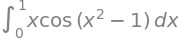

In [43]:
integ = sy.Integral(x * sy.cos(x**2 - 1), (x, 0, 1)) # integrate()랑 사용법이 완전 같습니다.
integ

치환 적분은 보통 다음의 형태의 공식을 이용하는데요,

$$
\int_a^b \mathinner{f(g(x)) g'(x)} dx = \int_{g(a)}^{g(b)} \mathinner{f(u)} du
$$

SymPy에서는 위에서 생성한 `Integral`에 `transform(expr, symbol)`메소드를 활용하여  치환 적분이 가능합니다.

예를 들어서, $u := x^2-1$에 대해서 치환 적분을 한다면, 다음과 같이 명령이 가능합니다.

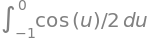

In [44]:
u = sy.symbols('u')
transformed = integ.transform(x**2 - 1, u)
transformed

그러면 이렇게 $u$에 대한 적분으로 치환된 형태의 함수가 얻어집니다.

이 `Integral`은 결국 `integrate()`의 과정에서 계산을 하는 과정을 수행하지 않고 남긴 형태의 객체인데요,

이 `Integral`에 실제로 계산을 명령하고 싶다면, `doit()`메소드를 이용하시면 됩니다. 말 그대로 해라! 에요.

In [45]:
transformed.doit() # 치환 후 적분값

In [46]:
integ.doit() #당연히 치환 전 적분값이랑 값은 동일합니다.

실제로 `integrate()`함수는 `Interal().doit()`과 완전히 동일한 구조로 설계된 함수입니다.

# 다항식

SymPy에는 평범한 모양과는 조금 다른 형태의 다항식 표현이 구현되어 있습니다.

그렇다고 막 엄청 특이하진 않구요, 기존의 $a_nx^n+...+a_1x+a_0$이라는 다항식을 계수 집합과 함꼐 저장하는 객체입니다.

```python
sy.Poly(expr, *gens)
```
간단합니다. `expr`에는 다항식 표현이 들어오구요, `*gens`에는 가변 인자로 다항식의 변수들의 상징을 넣습니다.

In [47]:
x = sy.symbols('x')
p = sy.Poly(1.0*x**2+x, x) # x^2 + x라는 다항식입니다.
p

위와 같이 $x^2+x$를 `1.0*x**2 + x`로 정의하면, 계수가 `float`, 즉 실수의 형태이므로 `Poly()`는 저걸 실수 계수 다항식으로 자동으로 생각하여 정의합니다.

마찬가지로 

In [48]:
p = sy.Poly(sy.S.Half*x**2+x, x)
p

와 같이, 유리수 객체 `S.Half`를 이용하면, 저 친구는 자동으로 계수가 유리수인 다항식으로 생각합니다.

물론 `sy.Poly()`에 추가 파라미터로 `domain = 'CC'` 등으로 직접적으로 사용자가 계수 집합을 지정할 수도 있습니다.

범위는 지정의 옵션은 다음과 같습니다 :

- `'ZZ'` : 정수
- `'QQ'` : 유리수
- `'RR'` : 실수
- `'CC'` : 복소수
- `'EX'` : 제한 없음(범용적이지만, 그만큼 무겁습니다.)

이 `Poly` 객체에도 다양한 유용한 메소드들이 있습니다.

예를 들어 `all_coeffs()` 메소드는 다항식의 계수들을 차수가 높은 순서대로 리스트에 담아서 반환합니다.

In [49]:
p.all_coeffs() # 위의 p가 1/2x^2 + x + 0이니, 1/2, 1, 0이 반환

참고로 `Poly()`를 이용할 때, 표현 대신에 이 계수 리스트를 넘겨서도 다항식 생성이 가능합니다.

In [50]:
q = sy.Poly(p.all_coeffs(),x) 
q # p의 계수 행렬을 그대로 넘겨서 p랑 형태가 같습니다.

그리고 다항식의 차수는 `degree()`메소드로 얻을 수 있습니다.

In [51]:
p.degree()

또 `Poly()`의 모양 그 자체는 SymPy의 다항식 모양이 아닌데요, 이 모양을 불러오고 싶다면 속성 `expr`을 불러오면 됩니다.

In [52]:
p.expr

그리고 이런 다항식에도 미분이 가능합니다 :

In [53]:
p.diff()

또 다항식은 대수학적으로, 복소수 공간까지 허용하여 생각한다면,

항상 그의 차수만큼의 복소근이 존재합니다.(대수학의 기본정리)

`all_roots()`메소드를 이용하면 이러한 복소근을 모두 계산하여 리스트에 넣어 받아볼 수 있습니다.

In [55]:
p = sy.Poly(x**3 + x**2 +2*x + 2)
p.all_roots()

만약 실수근만 관심이 있다면 `real_roots()`메소드를 사용하시면 됩니다.

In [56]:
p.real_roots()

그리고 대수학의 아벨-루피니 정리에 다르면, 5차 이상의 일반적인 다항식의 해는

사칙연산과 거듭제곱근만으로는 해를 표현할 수 없는데요, 따라서 예를 들어 다음과 같은 고차 방정식을 푼다면, 해가 이상해집니다.

In [57]:
p = sy.Poly(x**7 + x**2 +2*x + 2)

p.all_roots()

엄청 이상한 게 많은데요, 그냥 간단히 우리가 알고 있는 모양으로 표현할 수 없는 친구들은 SymPy가 계산은 하는데요,

그 모양을 아벨-루피니에 의해서 정확히 표현할 수 없기 떄문에, 저렇게 `CRootsOf`의 형태로 보여주는에요.

보시다시피 표현 가능한 해는 저렇게 멀쩡히 `-1`로 잘 보여지고, 나머지에서 괄호에 들어오는 표현은 우리의 원래 다항식의 표현이구요,

그 옆에 있는 숫자는 몇번째 근인지를 표현해주는 인덱스입니다.

모양이 이상해도 계산만큼은 정확합니다. 저걸 만약 `evalf()`를 이용하여 수치적으로 표현한다면, 다음의 형태가 됩니다.

In [58]:
[p.evalf() for p in p.all_roots()] # 시간이 좀 걸립니다. 5초 정도?

보통 다항식은 변수가 하나인 친구들이 다뤄지는데요,

더 나아가 다변수 다항식(Multivariate Polynomial)이라는 친구들도 있습니다.
$$P(x_1, \dots, x_n) = \sum_{i_1, \dots, i_n} a_{i_1, \dots, i_n} x_1^{i_1} x_2^{i_2} \dots x_n^{i_n}$$

그냥 간단하게 여러 변수가 등장하고, 걔네들끼리 곱해져서, 지수가 있는 친구들이 더해지는 형태에요.

`Poly()`는 이러한 다변수 다항식도 정의 가능합니다. 

In [59]:
p = sy.Poly(y**2*x**3 + x**2 +2*x + 2,x,y)
p

다변수 다항식은 차수는 모든 항의 변수들의 지수를 더한 것들 중 가장 높은 것으로 정의되는데요,

이는 `total_degree()`로 불러올 수 있습니다.

In [60]:
p.total_degree()

변수별(하나의 변수에 대한 다항식으로 간주했을 때의)로 차수가 궁금하다면, 기존의 `degree()` 메소드에 기준이 되는 상징을 넣어줍니다.

In [61]:
p.degree(y)

그리고 각 변수별로, 가장 가능한 최고차는 `degree_list()`로 불러올 수 있습니다.

In [62]:
p.degree_list()

# 극한값

SymPy로는 심지어 함수의 극한값도 다룰 수 있습니다. 이를 위해서는 함수이자 메소드인 `limit()`를 사용합니다 :

~~~python
sympy.limit(expr, x, x0, dir = '+')
expr.limit(x, x0, dir = '+')
~~~

`expr`은 함수의 형태를 보여주는 표현이구요, `x`는 그 함수에서 변수 역할을 할 상징이 들어갑니다.

`x0`은 극한의 목표가 되는 지점, `dir`은 극한의 방향(우극한은 `'+'`, 좌극한은 `'-'`, 양방향은 `'+-'`)이 들어갑니다.

이 때, `dir`의 디폴트는 수학에서처럼 양방향이지 않을까 하실 수 있는데요, 위에서 보시다시피 우극한 `+`입니다.

이는 수학적으로 어떤 수에 접근할때 일반적으로 더 큰 쪽에서 작은 쪽으로 접근하는 컨벤션과

복소 평면에서의 문제 떄문에 그렇게 결정되었습니다.

여튼 위의 명령어는 결국 다음을 계산하여 반환합니다.

$$
\lim_{x \to 0+} expr(x)
$$

In [63]:
x = sy.symbols('x')
sy.limit(1/x, x, 0) # 만약 발산하는 경우에는 이렇게 sy.Infinity를 반환합니다. 디폴트가 우극한이라 양의 무한대에요

In [64]:
x = sy.symbols('x')
sy.limit(1/x, x, 0, '-') # 이번엔 dir = -로 지정하여

In [65]:
sy.limit(1/x, x, 0, '+-') # 참고로 양방향으로 하면 sy.ComplexInfinity라는 놈을 반환합니다.

SymPy는 일반적으로는 로피탈의 정리가 필요한 $\lim_{x\to0}\frac{\sin(x)}{x}$같은 극한도 간단하게 계산해냅니다 :

In [66]:
sy.limit(sy.sin(x) / x, x, 0)

In [67]:
sy.limit(sy.log(x) / x, x, sy.oo)

다음과 같은 놈의 극한은 존재하지 않는데요,

$$
\lim_{x \to 0} \sin\left(\frac{1}{x}\right)
$$

이는 다른 말로, 집적점(Accumulation Point)이 2개 이상이거나, 아예 없는 경우라고도 표현할 수 있습니다.

집적점은 쉽게 말해서, 함수/수열이 엄청 자주 모이는 지점을 의미합니다.

예를 들어서, $(-1)^n$은 수렴하지 않지만, $-1$과 $1$의 값에 무한히 많이 번갈아 머무는 형태가 되는데요,

이런 점 $1,-1$을 $(-1)^n$의 집적점이라 합니다. 만약 집적점이 하나면 그건 그 수열/극한이 수렴한다는 의미이구요.

마찬가지로 위의 극한도, $x$가 0에 접근함에 따라서, 값이 요동치지만, $-1$과 $1$을 거의 무한히 많이 왔다갔다하여,

이들을 집적점으로 가집니다.

이렇게 극한이 존재하지 않지만, 그래도 집적점이라도 있는 경우에 `limit()`는 

가장 큰 집적점과 작은 집적점이 만들어내는 구간을 반환합니다. 그 범위 안에서 요동친다 이걸 알려주기 위해서에요.

이 때, 반환되는 객체는 진짜 구간 객체 `Interval`은 아니구요, `AccumulationBounds`라는 특수한 객체입니다.

이 놈은 구간에서처럼 일반적인 집합 연산은 불가능하나, 구간의 합 및 곱(두 구간을 합하고, 곱하는)은 지원합니다.

In [68]:
accum = sy.limit(sy.sin(1/x), x, 0)
accum #AccumulationBounds가 반환됩니다.

In [69]:
(accum + 1)**2 # 구간 연산들

## 전제 조건

상징적인 극한을 다룰 떄에는 보통 표현에 등장하는 추가적인 정보가 필요한 경우가 많습니다.

예를 들어

$$
\lim_{x \to \infty} x^n
$$
라는 극한은 $n$이 어떤 친구인지에 따라서 결정됩니다.

따라서 우리는 $n$에 대한 추가적인 전제 조건을 알려줘야합니다.

전제조건이 없다면 $x^n$의 $x\to \infty$의 극한은 다음과 같은 형태가 됩니다.

In [70]:
x,n = sy.symbols('x,n')
sy.limit(x**n, x, sy.oo)

우리가 필요한건 $n$에 대한 조건일 뿐이니, $n$을 정의하는 순간에 조건을 적어주면 됩니다 :

In [71]:
npos = sy.symbols('n', positive=True)
print(sy.limit(x**npos, x, sy.oo))

nneg = sy.symbols('n', negative = True)
print(sy.limit(x**nneg,x,sy.oo))

oo
0


## 급수

SymPy는 급수의 해석적인 형태와 부분합도 표현할 수 있습니다.

부분합이나 급수나 일단 기호적으로는 둘 다 합이잖아요? 따라서 다음의 함수를 사용합니다.

```python
sy.summation(expr, *symbols)
```

간단합니다. `expr`은 피가산항의 표현을 적어주고, `*symbols`에는 `(k,start,end)`의 형태로 급수/부분합을 타고 갈 인덱스,

그리고 더해질 `k`의 범위를 `start,end`로 넣어 전달해주면 됩니다.

만약 투플을 여러 개 전달한다면 결과물은 연쇄적인(nested) 합기호가 됩니다.

예를 들어 기하 급수는 다음과 같은 형태인데요
$$
\sum_{k=0}^\infty x^k
$$

이 놈은 다음과 같이 정의해줄 수 있습니다.

In [72]:
k = sy.symbols('k')
sy.summation(x**k, (k, 0, sy.oo))

⎧   1                 
⎪ ─────    for │x│ < 1
⎪ 1 - x               
⎪                     
⎪  ∞                  
⎪ ___                 
⎨ ╲                   
⎪  ╲    k             
⎪  ╱   x    otherwise 
⎪ ╱                   
⎪ ‾‾‾                 
⎪k = 0                
⎩                     

우리는 $x$의 범위를 지정하지 않았으므로, 저렇게 $x$의 범위에 따라 달라지는 `sy.Piecewise`객체가 반환됩니다.

만약 아래의 합기호 형태의 놈을 얻고 싶다면 `sy.Sum()`을 같은 문법으로 사용하시면 됩니다.

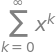

In [73]:
xpos = sy.symbols('x')
sy.Sum(x**k,(k,0,sy.oo))

마찬가지로 부분합도 똑같이 구현 가능합니다.

$$
\sum_{k=0}^n x^k
$$

In [74]:
sy.summation(x**k, (k, 0, n))

⎧  n + 1     for x = 1
⎪                     
⎪     n + 1           
⎨1 - x                
⎪──────────  otherwise
⎪  1 - x              
⎩                     

근데 급수와 달리, 유한합인 부분합은 otherwise의 경우에 급수 형태가 아니라, 저렇게 유한합을 단순화한 형태가 됩니다.

이는 계속 설명했었던 심파이가 객체들을 최대한 단순한 형태로 유지하는 결과입니다. 유한합의 경우 저런 공식으로 다루는 게 더 간단하거든요.

이의 일환으로 만약 다음과 같이 $n$값을 구체적인 숫자로 고정한다면, `summation`은 `Piecewise`가 아닌 `Add`형태의 객체를 반환하게 됩니다.

In [75]:
sy.summation(x**k,(k,0,10)) # Add가 반환됨.

그래서 유한합은 굳이 굳이 급수 모양으로 하고싶으시다면 `Sum()`을 사용하셔야합니다.

근데 그럴 필요가 거의 없긴 해요. `Add`객체로 생성되더라도 매우 좋거든요.

우리는 위에서 연쇄적인 nested된 합들도 구현할 수 있음을 다뤘었는데요,|

$$
\sum_{k=1}^n \sum_{j=1}^k j
$$

이런 친구를 정의하면 유한합은 `Add`를 반환하므로, 저 복잡하게 연쇄되는 부분합을 푼 형태가 바로 계산되어 나옵니다 :

In [76]:
j = sy.symbols('j')
sy.summation(j, (j, 1, k), (k, 1, n))